# 04 - Text CNN
Owner: Engineer 3

1D convolutions over embeddings at a few filter widths, max-pooled and concatenated. Tries a couple of filter configs, keeps the best.

Result: macro-F1 0.9851, accuracy 0.9992. Beats the TF-IDF baseline and LSTM.

## 1. Setup
Same as earlier notebooks.

In [1]:
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/Manzi453/Formative_2-Group_19.git"
BRANCH = "feature/baseline-tfidf"  # change to main once merged

if "google.colab" in sys.modules:
    if not Path("Formative_2-Group_19").exists():
        subprocess.run(["git", "clone", "-b", BRANCH, REPO_URL], check=True)
    os.chdir("Formative_2-Group_19")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    if Path.cwd().name == "notebooks":
        os.chdir("..")

sys.path.insert(0, str(Path.cwd()))
print("Working directory:", Path.cwd())

Working directory: /Users/manziivan453icloud.com/Downloads/Projects/Ivan /Formative_2-Group_19


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from src.utils import set_seed, SEED, RESULTS_DIR, MODELS_DIR
from src.data_loader import load_raw, make_split, ID_COL, TEXT_COL, LABEL_COL
from src.preprocessing import STRATEGIES
from src.nn_data import build_vocab, encode_batch, encode_labels, DEFAULT_MAX_LEN
from src.nn_models import CNNClassifier
from src.nn_train import train_classifier, predict_logits
from src.eda import length_features
from src.evaluation import compute_metrics, per_class_report, confusion
from src.plotting import save_fig, plot_confusion_matrix, plot_learning_curves
from src.experiments import log_experiment, EXPERIMENTS_CSV

set_seed()
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50, "display.width", 140)

METRICS = RESULTS_DIR / "metrics"
ERRORS = RESULTS_DIR / "errors"
PREDICTIONS = RESULTS_DIR / "predictions"
CNN_DIR = MODELS_DIR / "cnn"
for d in (METRICS, ERRORS, PREDICTIONS, CNN_DIR):
    d.mkdir(parents=True, exist_ok=True)

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
print("seed =", SEED, "| torch", torch.__version__, "| device =", DEVICE)

seed = 42 | torch 2.14.0 | device = mps


## 2. Data, split & preprocessing
Uses notebook 02's preprocessing choice.

In [3]:
train, test, sample = load_raw()
train_df, val_df = make_split(train)
CLASS_ORDER = list(train_df[LABEL_COL].value_counts().index)

prep_log = pd.read_csv(METRICS / "preprocessing_experiments.csv")
prep_log = prep_log.drop_duplicates(subset="experiment_id", keep="last")  # re-running a notebook appends, not overwrites
best_row = prep_log.sort_values("validation_macro_f1", ascending=False).iloc[0]
PREP_STRATEGY = best_row["strategy"]
clean = STRATEGIES[PREP_STRATEGY]
print(f"Using preprocessing strategy '{PREP_STRATEGY}' "
      f"(validation macro-F1={best_row['validation_macro_f1']} for the TF-IDF baseline in notebook 02).")

train_text = train_df[TEXT_COL].map(clean)
val_text = val_df[TEXT_COL].map(clean)
y_train = encode_labels(train_df[LABEL_COL], CLASS_ORDER)
y_val = encode_labels(val_df[LABEL_COL], CLASS_ORDER)
print(f"train={len(train_df):,}  validation={len(val_df):,}  classes={CLASS_ORDER}")

Using preprocessing strategy 'A_minimal' (validation macro-F1=0.9747 for the TF-IDF baseline in notebook 02).
train=31,719  validation=7,931  classes=['sexual_violence', 'Physical_violence', 'emotional_violence', 'economic_violence', 'Harmful_Traditional_practice']


## 3. Vocabulary and encoding
Same rule as notebook 03. Sequence length fixed at 64 - this ablation is about filters, not length.

In [4]:
VOCAB = build_vocab(train_text, min_freq=2)
MAX_LEN = DEFAULT_MAX_LEN
X_train_full = encode_batch(train_text, VOCAB, MAX_LEN)
X_val_full = encode_batch(val_text, VOCAB, MAX_LEN)
print(f"vocabulary size (min_freq=2): {len(VOCAB):,} | max_len={MAX_LEN}")

vocabulary size (min_freq=2): 16,867 | max_len=64


## 4. Controlled experiments: filter sizes & filter count
Three quick configs, short budget, just to rank them.

In [5]:
ABLATION_CONFIGS = {
    "cnn_filters345_nf100": dict(filter_sizes=(3, 4, 5), num_filters=100),
    "cnn_filters234_nf100": dict(filter_sizes=(2, 3, 4), num_filters=100),
    "cnn_filters345_nf150": dict(filter_sizes=(3, 4, 5), num_filters=150),
}
EMBED_DIM = 100

ablation_rows = []
for exp_id, cfg in ABLATION_CONFIGS.items():
    torch.manual_seed(SEED)
    model = CNNClassifier(vocab_size=len(VOCAB), n_classes=len(CLASS_ORDER), embed_dim=EMBED_DIM, **cfg)
    _, _, best_f1, train_time = train_classifier(
        model, X_train_full, y_train, X_val_full, y_val,
        epochs=4, batch_size=2048, lr=1e-3, device=DEVICE, patience=2, seed=SEED, verbose=False,
    )
    ablation_rows.append({"experiment_id": exp_id, "filter_sizes": str(cfg["filter_sizes"]),
                           "num_filters": cfg["num_filters"],
                           "val_macro_f1": round(best_f1, 4), "train_time_s": round(train_time, 1)})
    print(f"{exp_id}: val_macro_f1={best_f1:.4f} ({train_time:.1f}s)")

ablation_results = pd.DataFrame(ablation_rows).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
ablation_results

cnn_filters345_nf100: val_macro_f1=0.8785 (31.1s)


cnn_filters234_nf100: val_macro_f1=0.7817 (24.8s)


cnn_filters345_nf150: val_macro_f1=0.8393 (37.7s)


,experiment_id,filter_sizes,num_filters,val_macro_f1,train_time_s
0,cnn_filters345_nf100,"(3, 4, 5)",100,0.8785,31.1
1,cnn_filters345_nf150,"(3, 4, 5)",150,0.8393,37.7
2,cnn_filters234_nf100,"(2, 3, 4)",100,0.7817,24.8


In [6]:
for _, row in ablation_results.iterrows():
    log_experiment(
        experiment_id=row["experiment_id"], model="cnn", preprocessing=PREP_STRATEGY,
        tokenizer="word_level_min_freq_2", sequence_length=MAX_LEN, embedding=f"learned_{EMBED_DIM}d",
        learning_rate=1e-3, batch_size=2048, epochs="<=4 (early stop)", optimizer="adam", dropout=0.3,
        train_time=f"{row['train_time_s']:.1f}s", macro_f1=row["val_macro_f1"],
        notes=f"Controlled ablation over filter_sizes={row['filter_sizes']}, num_filters={row['num_filters']}.",
        next_action="Winning config retrained with a larger epoch budget in section 5.",
    )

BEST_CONFIG_ID = ablation_results.iloc[0]["experiment_id"]
BEST_CONFIG = ABLATION_CONFIGS[BEST_CONFIG_ID]
print(f"Best config: {BEST_CONFIG_ID} -> {BEST_CONFIG}")

Best config: cnn_filters345_nf100 -> {'filter_sizes': (3, 4, 5), 'num_filters': 100}


## 5. Final model
Retrains the winner for longer.

In [7]:
torch.manual_seed(SEED)
final_model = CNNClassifier(vocab_size=len(VOCAB), n_classes=len(CLASS_ORDER), embed_dim=EMBED_DIM, **BEST_CONFIG)
final_model, history, best_f1, train_time = train_classifier(
    final_model, X_train_full, y_train, X_val_full, y_val,
    epochs=20, batch_size=2048, lr=1e-3, device=DEVICE, patience=5, seed=SEED, verbose=True,
)

val_logits = predict_logits(final_model, X_val_full, DEVICE)
val_pred_ids = val_logits.argmax(dim=1).numpy()
val_pred_labels = np.array(CLASS_ORDER)[val_pred_ids]
y_val_labels = np.array(CLASS_ORDER)[y_val]

metrics = compute_metrics(y_val_labels, val_pred_labels)
print(f"config={BEST_CONFIG_ID} | train_time={train_time:.1f}s | epochs_run={len(history['train_loss'])}")
pd.Series(metrics)

epoch  1/20 | train_loss 0.4555 | val_loss 0.2329 | val_macro_f1 0.3835


epoch  2/20 | train_loss 0.1825 | val_loss 0.0994 | val_macro_f1 0.4002


epoch  3/20 | train_loss 0.0686 | val_loss 0.0366 | val_macro_f1 0.7542


epoch  4/20 | train_loss 0.0311 | val_loss 0.0196 | val_macro_f1 0.8785


epoch  5/20 | train_loss 0.0185 | val_loss 0.0126 | val_macro_f1 0.9267


...

epoch 12/20 | train_loss 0.0034 | val_loss 0.0038 | val_macro_f1 0.9851


epoch 13/20 | train_loss 0.0033 | val_loss 0.0035 | val_macro_f1 0.9851


epoch 14/20 | train_loss 0.0027 | val_loss 0.0032 | val_macro_f1 0.9851
Early stopping at epoch 14 (no improvement for 5 epochs).


config=cnn_filters345_nf100 | train_time=84.5s | epochs_run=14


validation_accuracy    0.999243
macro_precision        0.998320
macro_recall           0.973654
macro_f1               0.985057
weighted_f1            0.999222
dtype: float64

## 6. Per-class performance, confusion matrix & learning curves

,precision,recall,f1-score,support
Harmful_Traditional_practice,1.000000,0.868421,0.929577,38.000000
Physical_violence,1.000000,1.000000,1.000000,1190.000000
economic_violence,1.000000,1.000000,1.000000,43.000000
emotional_violence,0.992366,1.000000,0.996169,130.000000
sexual_violence,0.999235,0.999847,0.999541,6530.000000
accuracy,0.999243,0.999243,0.999243,0.999243
macro avg,0.998320,0.973654,0.985057,7931.000000
weighted avg,0.999245,0.999243,0.999222,7931.000000


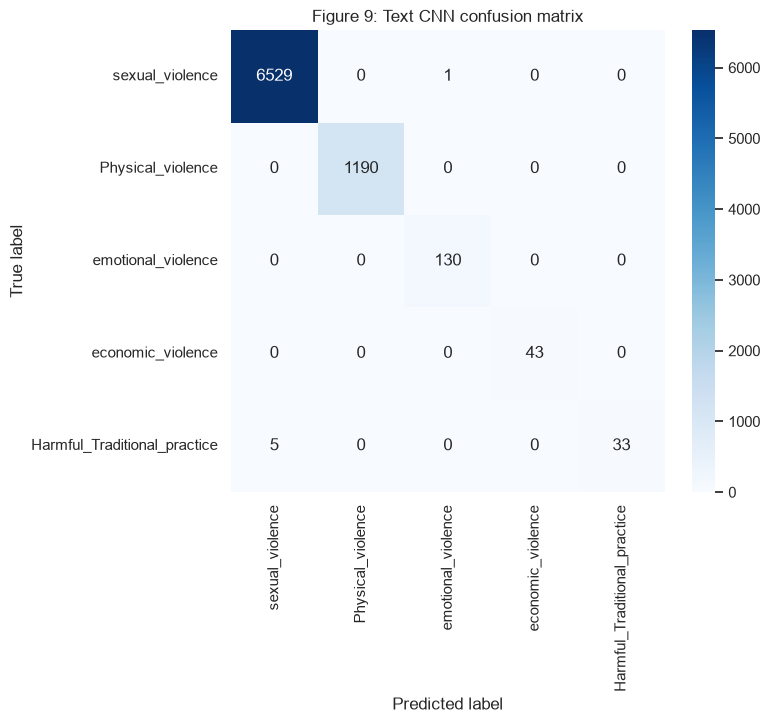

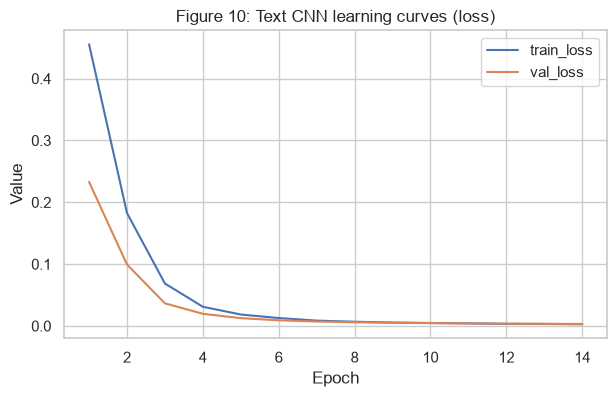

In [8]:
report = per_class_report(y_val_labels, val_pred_labels)
report.to_csv(METRICS / "cnn_per_class_report.csv")
display(report)

cm = confusion(y_val_labels, val_pred_labels, labels=CLASS_ORDER)
fig = plot_confusion_matrix(cm, CLASS_ORDER, "Figure 9: Text CNN confusion matrix")
save_fig(fig, "fig09_cnn_confusion_matrix")
plt.show()

fig2 = plot_learning_curves(
    {"train_loss": history["train_loss"], "val_loss": history["val_loss"]},
    "Figure 10: Text CNN learning curves (loss)",
)
save_fig(fig2, "fig10_cnn_learning_curves")
plt.show()

## 7. Error analysis
Misclassified IDs + labels only.

In [9]:
val_lengths = length_features(val_df, TEXT_COL)
mask = val_pred_labels != y_val_labels
errors = val_df.loc[mask, [ID_COL, LABEL_COL]].rename(columns={LABEL_COL: "true_label"}).copy()
errors["predicted"] = val_pred_labels[mask]
errors["tokens"] = val_lengths.loc[errors.index, "tokens"]
errors.to_csv(ERRORS / "cnn_errors.csv", index=False)

print(f"Misclassified: {len(errors)} / {len(val_df)} ({100 * len(errors) / len(val_df):.2f}%)")
errors.groupby(["true_label", "predicted"]).size().sort_values(ascending=False).head(10)

Misclassified: 6 / 7931 (0.08%)


true_label                    predicted         
Harmful_Traditional_practice  sexual_violence       5
sexual_violence               emotional_violence    1
dtype: int64

## 8. Save artifact and log run

In [10]:
CHECKPOINT_PATH = CNN_DIR / "cnn.pt"
torch.save({
    "state_dict": final_model.state_dict(),
    "vocab": VOCAB,
    "classes": CLASS_ORDER,
    "config": {**BEST_CONFIG, "embed_dim": EMBED_DIM, "max_len": MAX_LEN},
    "preprocessing": PREP_STRATEGY,
}, CHECKPOINT_PATH)

log_experiment(
    experiment_id="cnn_final_v1", model="cnn", preprocessing=PREP_STRATEGY,
    tokenizer="word_level_min_freq_2", sequence_length=MAX_LEN, embedding=f"learned_{EMBED_DIM}d",
    learning_rate=1e-3, batch_size=2048, epochs=len(history["train_loss"]), optimizer="adam", dropout=0.3,
    train_time=f"{train_time:.1f}s",
    validation_accuracy=round(metrics["validation_accuracy"], 4),
    macro_precision=round(metrics["macro_precision"], 4),
    macro_recall=round(metrics["macro_recall"], 4),
    macro_f1=round(metrics["macro_f1"], 4),
    weighted_f1=round(metrics["weighted_f1"], 4),
    notes=f"Text CNN, config={BEST_CONFIG_ID} chosen from the section-4 ablation.",
    next_action="Compare against TF-IDF baseline / LSTM / TCN / Transformer in notebook 07.",
)

val_predictions = val_df[[ID_COL]].assign(true_label=y_val_labels, predicted_label=val_pred_labels)
val_predictions.to_csv(PREDICTIONS / "cnn_val_predictions.csv", index=False)
print(f"Saved checkpoint to {CHECKPOINT_PATH}")
print(f"Saved predictions to {PREDICTIONS / 'cnn_val_predictions.csv'}")

Saved checkpoint to /Users/manziivan453icloud.com/Downloads/Projects/Ivan /Formative_2-Group_19/models/cnn/cnn.pt
Saved predictions to /Users/manziivan453icloud.com/Downloads/Projects/Ivan /Formative_2-Group_19/results/predictions/cnn_val_predictions.csv


## 9. Findings
Pulled straight from the tables above.

In [11]:
exp_log = pd.read_csv(EXPERIMENTS_CSV)
exp_log = exp_log.drop_duplicates(subset="experiment_id", keep="last")  # re-running a notebook appends, not overwrites
baseline_f1 = exp_log.loc[exp_log["experiment_id"] == "baseline_tfidf_logreg_v1", "macro_f1"].iloc[0]
lstm_f1 = exp_log.loc[exp_log["experiment_id"] == "lstm_final_v1", "macro_f1"]
lstm_f1 = float(lstm_f1.iloc[0]) if len(lstm_f1) else None

findings = {
    "preprocessing strategy (from notebook 02)": PREP_STRATEGY,
    "ablation configs compared": ", ".join(ABLATION_CONFIGS),
    "best config": f"{BEST_CONFIG_ID} ({BEST_CONFIG})",
    "final macro-F1": f"{metrics['macro_f1']:.4f}",
    "final accuracy": f"{metrics['validation_accuracy']:.4f}",
    "epochs run (early stopping, patience=3)": len(history["train_loss"]),
    "train time": f"{train_time:.1f}s",
    "misclassified (val)": f"{len(errors)} / {len(val_df)} ({100 * len(errors) / len(val_df):.2f}%)",
    "TF-IDF baseline macro-F1 (notebook 02)": f"{float(baseline_f1):.4f}",
    "CNN vs TF-IDF baseline": f"{metrics['macro_f1'] - float(baseline_f1):+.4f} macro-F1",
}
if lstm_f1 is not None:
    findings["LSTM macro-F1 (notebook 03)"] = f"{lstm_f1:.4f}"
    findings["CNN vs LSTM"] = f"{metrics['macro_f1'] - lstm_f1:+.4f} macro-F1"
pd.Series(findings, name="finding").to_frame()

,finding
preprocessing strategy (from notebook 02),A_minimal
ablation configs compared,"cnn_filters345_nf100, cnn_filters234_nf100, cn..."
best config,"cnn_filters345_nf100 ({'filter_sizes': (3, 4, ..."
final macro-F1,0.9851
final accuracy,0.9992
"epochs run (early stopping, patience=3)",14
train time,84.5s
misclassified (val),6 / 7931 (0.08%)
TF-IDF baseline macro-F1 (notebook 02),0.9747
CNN vs TF-IDF baseline,+0.0104 macro-F1
